Imports

In [23]:
# !pip install pyarrow
# !pip install --upgrade seaborn

In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import ast
from sklearn.preprocessing import StandardScaler

Load data

In [25]:
DEMO_J = pd.read_sas("./raw/2017_2018/DEMO_J.XPT")
BPX_J = pd.read_sas("./raw/2017_2018/BPX_J.XPT")
BMX_J = pd.read_sas("./raw/2017_2018/BMX_J.XPT")
CBC_J = pd.read_sas("./raw/2017_2018/CBC_J.XPT")
FERTIN_J = pd.read_sas("./raw/2017_2018/FERTIN_J.XPT")
VID_J = pd.read_sas("./raw/2017_2018/VID_J.XPT")
HSCRP_J = pd.read_sas("./raw/2017_2018/HSCRP_J.XPT")
BIOPRO_J = pd.read_sas("./raw/2017_2018/BIOPRO_J.XPT")
PAQ_J = pd.read_sas("./raw/2017_2018/PAQ_J.XPT")
ALQ_J = pd.read_sas("./raw/2017_2018/ALQ_J.XPT")
SMQ_J = pd.read_sas("./raw/2017_2018/SMQ_J.XPT")
SLQ_J = pd.read_sas("./raw/2017_2018/SLQ_J.XPT")
DUQ_J = pd.read_sas("./raw/2017_2018/DUQ_J.XPT")
WHQ_J = pd.read_sas("./raw/2017_2018/WHQ_J.XPT")
SMQRTU_J = pd.read_sas("./raw/2017_2018/SMQRTU_J.XPT")
DPQ_J = pd.read_sas("./raw/2017_2018/DPQ_J.XPT")

data_frames = {
    'DEMO': DEMO_J,
    'BPX': BPX_J,
    'BMX': BMX_J,
    'CBC': CBC_J,
    'FERTIN': FERTIN_J,
    'VID': VID_J,
    'HSCRP': HSCRP_J,
    'BIOPRO': BIOPRO_J,
    'PAQ': PAQ_J,
    'ALQ': ALQ_J,
    'SMQ': SMQ_J,
    'SMQRTU': SMQRTU_J,
    'DPQ': DPQ_J,
    'SLQ': SLQ_J,
    'DUQ': DUQ_J,
    'WHQ': WHQ_J
}



In [26]:
# codebook includes a description of each data file and variable, as well as a first pass at selecting model input and output variables

codebook = pd.read_csv('./raw/2017_2018/codebook_2017_2018.csv')
codebook.head()

,Variable Name,Variable Description,Data File Name,Data File Description,Begin Year,EndYear,Component,Use Constraints,Model Feature,Model Output,Column Alias,OHE,Value Encoding,Missing Data Remap?,Remap Value,Fill Zeros,Numeric
0,AIALANGA,Language of the MEC ACASI Interview Instrument,DEMO_J,Demographic Variables and Sample Weights,2017,2018,Demographics,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,DMDBORN4,In what country {were you/was SP} born?,DEMO_J,Demographic Variables and Sample Weights,2017,2018,Demographics,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,DMDCITZN,{Are you/Is SP} a citizen of the United States...,DEMO_J,Demographic Variables and Sample Weights,2017,2018,Demographics,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,DMDEDUC2,What is the highest grade or level of school {...,DEMO_J,Demographic Variables and Sample Weights,2017,2018,Demographics,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,DMDEDUC3,What is the highest grade or level of school {...,DEMO_J,Demographic Variables and Sample Weights,2017,2018,Demographics,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
for name, val in data_frames.items():
    print(codebook[codebook['Data File Name'] == f"{name}_J"]['Data File Description'].iloc[0])
    print('Shape: ', val.shape)
    print('n patients: ', val['SEQN'].nunique())
    print()

Demographic Variables and Sample Weights
Shape:  (9254, 46)
n patients:  9254

Blood Pressure 
Shape:  (8704, 21)
n patients:  8704

Body Measures
Shape:  (8704, 21)
n patients:  8704

Complete Blood Count with 5-Part Differential
Shape:  (8366, 22)
n patients:  8366

Ferritin 
Shape:  (7332, 3)
n patients:  7332

Vitamin D 
Shape:  (8366, 9)
n patients:  8366

High-Sensitivity C-Reactive Protein
Shape:  (8366, 3)
n patients:  8366

Standard Biochemistry Profile
Shape:  (6401, 41)
n patients:  6401

Physical Activity
Shape:  (5856, 17)
n patients:  5856

Alcohol Use
Shape:  (5533, 10)
n patients:  5533

Smoking - Cigarette Use
Shape:  (6724, 37)
n patients:  6724

Smoking - Recent Tobacco Use
Shape:  (6401, 27)
n patients:  6401

Mental Health - Depression Screener
Shape:  (5533, 11)
n patients:  5533

Sleep Disorders
Shape:  (6161, 11)
n patients:  6161

Drug Use
Shape:  (4572, 41)
n patients:  4572

Weight History
Shape:  (6161, 37)
n patients:  6161



In [28]:
from functools import reduce

# Prefix non-SEQN columns to avoid name collisions, then outer-merge all on SEQN
dfs = [df.rename(columns=lambda c: c if c == 'SEQN' else f"{name}_{c}") for name, df in data_frames.items()]
merged = reduce(lambda left, right: pd.merge(left, right, on='SEQN', how='outer'), dfs)
merged = merged.replace(5.397605346934028e-79, 0) # weird things happening when value = 0 in sas files

print(merged.shape)
print(merged['SEQN'].nunique())

(9254, 342)
9254


In [29]:
# select columns from `merged` where codebook marks them as model feature or model output
def _find_col(codebook, keywords):
    for c in codebook.columns:
        low = c.lower()
        if all(k in low for k in keywords):
            return c
    for c in codebook.columns:
        low = c.lower()
        if any(k in low for k in keywords):
            return c
    return None

var_col = _find_col(codebook, ['var']) or _find_col(codebook, ['name']) or _find_col(codebook, ['column'])
feat_col = _find_col(codebook, ['model','feature']) or _find_col(codebook, ['feature'])
out_col = _find_col(codebook, ['model','output']) or _find_col(codebook, ['output'])
dfname_col = _find_col(codebook, ['data file']) or _find_col(codebook, ['file'])

if var_col is None:
    raise ValueError("Couldn't locate variable name column in codebook.")

# build boolean mask for rows flagged as feature or output (accepts True/False, 1/0, 'true'/'1', etc.)
masks = []
for col in (feat_col, out_col):
    if col is not None:
        s = codebook[col].astype(str).str.lower()
        masks.append(s.isin(['1','true','t','y','yes'] ) | (pd.to_numeric(codebook[col], errors='coerce')>0).fillna(False))
if not masks:
    raise ValueError("Couldn't find feature/output flag columns in codebook.")
mask = masks[0]
for m in masks[1:]:
    mask = mask | m

selected_rows = codebook.loc[mask].dropna(subset=[var_col])

# construct merged column names: prefix from data file name (e.g. 'WHQ_J' -> 'WHQ') + '_' + variable
def merged_col_name(row):
    var = str(row[var_col]).strip()
    if var.upper() == 'SEQN':
        return 'SEQN'
    dfname = ''
    if dfname_col and pd.notna(row.get(dfname_col)):
        dfname = str(row[dfname_col])
    prefix = dfname.replace('_J','').rstrip('_') if dfname else ''
    return f"{prefix}_{var}" if prefix else var

cols = [merged_col_name(r) for _, r in selected_rows.iterrows()]
cols = ['SEQN'] + [c for c in cols if c in merged.columns and c != 'SEQN']

merged_selected = merged[cols].copy()

# apply alias names from codebook (Column Alias) except for SEQN; ensure unique column names
alias_map = {}
used_aliases = set(merged_selected.columns)  # avoid collisions with existing names
for _, row in selected_rows.iterrows():
    col = merged_col_name(row)
    if col == 'SEQN' or col not in merged_selected.columns:
        continue
    alias = row.get('Column Alias')
    if pd.isna(alias):
        continue
    alias = str(alias).strip()
    if not alias or alias.upper() == 'SEQN':
        continue
    final_alias = alias
    i = 1
    while final_alias in used_aliases:
        final_alias = f"{alias}_{i}"
        i += 1
    alias_map[col] = final_alias
    used_aliases.add(final_alias)

if alias_map:
    merged_selected.rename(columns=alias_map, inplace=True)

merged_selected.shape

(9254, 94)

## Check outputs

How many participants completed all questions of the 2017/2018 depression screener? (model output)


In [30]:
output_cols = list(codebook[codebook['Model Output'] == True]['Column Alias'])
# output_cols = [f"DPQ_{col}" if not col.startswith("DPQ_") else col for col in output_cols]

merged_outputs = merged_selected[['SEQN'] + [col for col in output_cols if col in merged_selected.columns]]

# drop refusals and missing surveys
merged_outputs = merged_outputs[(merged_outputs[output_cols] <= 3).all(axis=1)]
merged_outputs.dropna(subset=output_cols, how='all').shape

(5068, 10)

What kind of distribution of scores are we working with? 

On interpretation of the PHQ-9: 
- On the PHQ-9 depression scale, a score of 10 or higher is generally considered "bad" (moderate to severe depression) and indicates a need for clinical treatment. Scores range from 0–27, with higher numbers indicating more severe symptoms: 10-14 (moderate), 15-19 (moderately severe), and 20+ (severe). 

        PHQ-9 Score Interpretation:
        0–4: Minimal or no depression
        5–9: Mild depression (support and education)
        10–14: Moderate depression (consider counseling/medication)
        15–19: Moderately severe depression (active treatment recommended)
        20–27: Severe depression (active treatment required)

In [31]:
# calculate sum of dpq scores
dpq_cols = [col for col in merged_outputs.columns if col.startswith("dpq_")]
merged_outputs["dpq_total"] = merged_outputs[dpq_cols].sum(axis=1)

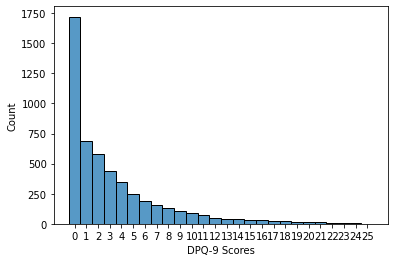

In [32]:
sns.histplot(merged_outputs['dpq_total'], discrete=True)
plt.xticks(np.arange(merged_outputs['dpq_total'].min(), merged_outputs['dpq_total'].max() + 1, 1))
plt.xlabel('DPQ-9 Scores')
plt.show()

In [33]:
# what about categories?

def remap_dpq_9(x):
    if x >= 0 and x <= 4:
        return "Minimal or no depression"
    if x >= 5 and x <= 9:
        return "Mild depression"
    if x >= 10 and x <= 14:
        return "Moderate depression"
    if x >= 15 and x <= 19:
        return "Moderately severe depression"
    if x >= 20:
        return "Severe depression"
    
merged_outputs["depression_category"] = merged_outputs["dpq_total"].apply(remap_dpq_9)
print(merged_outputs["depression_category"].value_counts())
print("")


# counts for if depression is of clinical concern (binary)
def remap_dpq_9_binary(x):
    if x >= 10:
        return True
    else:
        return False
    
merged_outputs["depression_binary"] = merged_outputs["dpq_total"].apply(remap_dpq_9_binary)
print(merged_outputs["depression_binary"].value_counts())
print(f"{len(merged_outputs[merged_outputs['depression_binary'] == True])/ len(merged_outputs) * 100:.2f}% of patients in set have depression of clinical concern.")

depression_category
Minimal or no depression        3772
Mild depression                  837
Moderate depression              292
Moderately severe depression     124
Severe depression                 43
Name: count, dtype: int64

depression_binary
False    4609
True      459
Name: count, dtype: int64
9.06% of patients in set have depression of clinical concern.


### Prepping data for modeling

In [34]:
# codebook reload for convenience
codebook = pd.read_csv('./raw/2017_2018/codebook_2017_2018.csv')

feature_cols = codebook[(codebook['Model Feature'] == True) & (codebook['Variable Name'] != 'SEQN')]['Column Alias'].values
feature_cols = np.insert(feature_cols, 0, 'SEQN')

# make a copy of data for model prep
df = merged_selected.copy()

# select feature columns
df = df[feature_cols]

In [35]:
# remap questionnaire values to descriptive labels

ohe_cols = codebook[codebook['OHE'] == True]['Column Alias'].values

for col in ohe_cols:
    remap_dict = ast.literal_eval(codebook[codebook['Column Alias'] == col]['Value Encoding'].iloc[0])
    df[col] = df[col].map(remap_dict)

# one hot encode descriptive labels
df = pd.get_dummies(df, columns=ohe_cols)

In [36]:
# Some questionnaire responses should be mapped to Null values
remap_null_cols = codebook[codebook['Missing Data Remap?'] == True]['Column Alias'].values

for col in remap_null_cols:
    remap_val = codebook[codebook['Column Alias'] == col]['Remap Value'].iloc[0]
    df[col] = df[col].replace(remap_val, np.nan)

In [37]:
# some questionnaire responses should have nulls mapped to zero
remap_zeros = codebook[codebook['Fill Zeros'] == True]['Column Alias'].values

for col in remap_zeros:
    df[col] = df[col].fillna(0)

### Before Imputation

In [38]:
df.describe()

,SEQN,age,2_year_interview_weight,2_year_mec_exam_weight,heart_rate,diastolic_bp_1,diastolic_bp_2,diastolic_bp_3,mil,systolic_bp_1,...,days_snuff,days_nicotine_replacement,days_hookah,days_ecigarette,hours_slept_weekday,hours_slept_weekend,recent_cocaine_use,recent_heroin_use,recent_meth_use,recent_alcohol_use
count,9254.000000,9254.000000,9254.000000,9254.000000,1539.000000,6302.000000,6563.000000,6538.000000,6731.000000,6302.000000,...,9254.000000,9254.000000,9254.000000,9254.000000,6113.000000,6104.000000,9254.000000,9254.000000,9254.000000,9254.000000
mean,98329.500000,34.334234,34670.706829,34670.706829,109.009747,67.843224,68.298339,68.284797,146.931214,121.331006,...,0.021396,0.008321,0.004971,0.043225,7.658842,8.378195,0.034796,0.013724,0.037497,1.965528
std,2671.544029,25.500280,41356.667327,43343.996803,22.563692,16.359888,16.160332,16.258664,20.636049,19.978704,...,0.313562,0.178965,0.114718,0.423903,1.669706,1.781355,0.751438,0.571794,0.878677,34.309035
min,93703.000000,0.000000,2571.068712,0.000000,60.000000,0.000000,0.000000,0.000000,100.000000,72.000000,...,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,96016.250000,11.000000,13074.433246,12347.311890,92.000000,60.000000,60.000000,60.000000,130.000000,106.000000,...,0.000000,0.000000,0.000000,0.000000,7.000000,7.000000,0.000000,0.000000,0.000000,0.000000
50%,98329.500000,31.000000,21098.454260,21059.894454,106.000000,70.000000,70.000000,70.000000,140.000000,118.000000,...,0.000000,0.000000,0.000000,0.000000,8.000000,8.000000,0.000000,0.000000,0.000000,0.000000
75%,100642.750000,58.000000,36923.316352,37561.998020,124.000000,76.000000,78.000000,78.000000,160.000000,132.000000,...,0.000000,0.000000,0.000000,0.000000,8.500000,9.500000,0.000000,0.000000,0.000000,0.000000
max,102956.000000,80.000000,433085.005262,419762.836488,180.000000,136.000000,136.000000,134.000000,260.000000,228.000000,...,5.000000,5.000000,5.000000,5.000000,14.000000,14.000000,30.000000,30.000000,30.000000,777.000000


In [39]:
# scale numeric data
scale_cols = codebook[codebook['Numeric'] == True]['Column Alias'].values

# bootstrap impute
rng = np.random.default_rng(42)
df_bootstrap = df.copy()

for col in scale_cols:
    # check if there are any nulls
    mask = df_bootstrap[col].isna().values
    if mask.any():
        observed = df_bootstrap.loc[~mask, col].values
        
        if observed.size > 0:
            df_bootstrap.loc[mask, col] = rng.choice(
                observed,
                size=mask.sum(),
                replace=True
            )

# mean impute
for col in scale_cols:
    df[col] = df[col].fillna(df[col].mean())

### Bootstrap Imputation 

We see below that some column's standard deviation (and therefore variance) are different across the non-imputed, bootstrap imputed, and mean imputed data. We opt for bootstrap imputation because the variances are preserved slightly closer to the non-imputed data.

In [40]:
df_bootstrap[scale_cols].describe()

,age,2_year_interview_weight,2_year_mec_exam_weight,heart_rate,diastolic_bp_1,diastolic_bp_2,diastolic_bp_3,mil,systolic_bp_1,systolic_bp_2,...,days_snuff,days_nicotine_replacement,days_hookah,days_ecigarette,hours_slept_weekday,hours_slept_weekend,recent_cocaine_use,recent_heroin_use,recent_meth_use,recent_alcohol_use
count,9254.000000,9254.000000,9254.000000,9254.000000,9254.000000,9254.000000,9254.000000,9254.000000,9254.000000,9254.000000,...,9254.000000,9254.000000,9254.000000,9254.000000,9254.000000,9254.000000,9254.000000,9254.000000,9254.000000,9254.000000
mean,34.334234,34670.706829,34670.706829,108.841150,67.862978,68.382753,68.371515,146.790577,121.589367,121.677113,...,0.021396,0.008321,0.004971,0.043225,7.657608,8.394370,0.034796,0.013724,0.037497,1.965528
std,25.500280,41356.667327,43343.996803,22.576609,16.186882,16.047240,16.102553,20.452273,20.129913,20.497000,...,0.313562,0.178965,0.114718,0.423903,1.675046,1.789168,0.751438,0.571794,0.878677,34.309035
min,0.000000,2571.068712,0.000000,60.000000,0.000000,0.000000,0.000000,100.000000,72.000000,72.000000,...,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,11.000000,13074.433246,12347.311890,92.000000,60.000000,60.000000,60.000000,130.000000,106.000000,106.000000,...,0.000000,0.000000,0.000000,0.000000,7.000000,7.000000,0.000000,0.000000,0.000000,0.000000
50%,31.000000,21098.454260,21059.894454,106.000000,70.000000,70.000000,70.000000,140.000000,118.000000,118.000000,...,0.000000,0.000000,0.000000,0.000000,8.000000,8.000000,0.000000,0.000000,0.000000,0.000000
75%,58.000000,36923.316352,37561.998020,124.000000,76.000000,78.000000,78.000000,160.000000,132.000000,132.000000,...,0.000000,0.000000,0.000000,0.000000,8.500000,9.500000,0.000000,0.000000,0.000000,0.000000
max,80.000000,433085.005262,419762.836488,180.000000,136.000000,136.000000,134.000000,260.000000,228.000000,236.000000,...,5.000000,5.000000,5.000000,5.000000,14.000000,14.000000,30.000000,30.000000,30.000000,777.000000


### Mean Imputation

In [41]:
df[scale_cols].describe()

,age,2_year_interview_weight,2_year_mec_exam_weight,heart_rate,diastolic_bp_1,diastolic_bp_2,diastolic_bp_3,mil,systolic_bp_1,systolic_bp_2,...,days_snuff,days_nicotine_replacement,days_hookah,days_ecigarette,hours_slept_weekday,hours_slept_weekend,recent_cocaine_use,recent_heroin_use,recent_meth_use,recent_alcohol_use
count,9254.000000,9254.000000,9254.000000,9254.000000,9254.000000,9254.000000,9254.000000,9254.000000,9254.000000,9254.000000,...,9254.000000,9254.000000,9254.000000,9254.000000,9254.000000,9254.000000,9254.000000,9254.000000,9254.000000,9254.000000
mean,34.334234,34670.706829,34670.706829,109.009747,67.843224,68.298339,68.284797,146.931214,121.331006,121.614810,...,0.021396,0.008321,0.004971,0.043225,7.658842,8.378195,0.034796,0.013724,0.037497,1.965528
std,25.500280,41356.667327,43343.996803,9.199136,13.500312,13.609028,13.665729,17.599195,16.486588,17.241905,...,0.313562,0.178965,0.114718,0.423903,1.357033,1.446708,0.751438,0.571794,0.878677,34.309035
min,0.000000,2571.068712,0.000000,60.000000,0.000000,0.000000,0.000000,100.000000,72.000000,72.000000,...,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,11.000000,13074.433246,12347.311890,109.009747,64.000000,64.000000,64.000000,140.000000,112.000000,112.000000,...,0.000000,0.000000,0.000000,0.000000,7.000000,8.000000,0.000000,0.000000,0.000000,0.000000
50%,31.000000,21098.454260,21059.894454,109.009747,67.843224,68.298339,68.284797,146.931214,121.331006,121.614810,...,0.000000,0.000000,0.000000,0.000000,7.658842,8.378195,0.000000,0.000000,0.000000,0.000000
75%,58.000000,36923.316352,37561.998020,109.009747,74.000000,74.000000,74.000000,150.000000,124.000000,126.000000,...,0.000000,0.000000,0.000000,0.000000,8.000000,9.000000,0.000000,0.000000,0.000000,0.000000
max,80.000000,433085.005262,419762.836488,180.000000,136.000000,136.000000,134.000000,260.000000,228.000000,236.000000,...,5.000000,5.000000,5.000000,5.000000,14.000000,14.000000,30.000000,30.000000,30.000000,777.000000


### Standardizing Numeric Column

In [42]:
scaler = StandardScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])
df_bootstrap[scale_cols] = scaler.fit_transform(df_bootstrap[scale_cols])

In [43]:
# join outputs so that we select for patients who did the DPQ-9, and get our labels
outputs = merged_outputs.copy()
df = df.merge(outputs, on = 'SEQN')

In [44]:
# write to parquet for future use
df.to_parquet('model_ready_boostrap_imputed.parquet', compression='snappy')